In [124]:
import re
import pandas as pd
import numpy as np
from dateutil.parser import parse
import matplotlib as mpl
from matplotlib import pyplot as plt
mpl.style.use('dark_background')

pattern = re.compile(r"\[(?P<timestamp>.*?)\] numPlayouts: (?P<numPlayouts>.*?), win: (?P<win>.*?), lose: (?P<lose>.*?), tie: (?P<tie>.*?), avgCurrStarted: (?P<avgCurrStarted>.*)")

results = []

with open("new_results.log", "r") as f:
    for line in f.readlines():
        assert line != "", "Empty line"
        match = pattern.search(line)
        if match is not None:
            results += [match.groupdict()]

df = pd.DataFrame(results)
df["numPlayouts"] = df["numPlayouts"].astype(int)
df["win"] = df["win"].astype(int)
df["lose"] = df["lose"].astype(int)
df["tie"] = df["tie"].astype(int)
df["avgCurrStarted"] = df["avgCurrStarted"].astype(float)
df["timestamp"] = df["timestamp"].map(lambda t: parse(t, fuzzy=True))

# Strength, explained later
df["strength"] = ((df["win"] + df["tie"] / 2) * df["numPlayouts"] / 1000).astype(int)

In [116]:
corrs = df.corr()
def autocorr(f: str) -> float:
    corr = corrs.loc["timestamp", f]
    if pd.isna(corr):
        return .0
    return corr

In [117]:
# Fairness of Evaluation

round_fairness_significance = .05
n_evaluation_games = 10

n_total_games = len(df) * n_evaluation_games
mean_total_games = int(round(df['avgCurrStarted'].mean() * n_total_games))
std_total_games = int(round(df['avgCurrStarted'].std() * n_total_games))

round_fairness = df["avgCurrStarted"].mean() - .5
round_fairness_autocorr = autocorr("avgCurrStarted")

round_fairness_doubt = False

print(f"[Info] The first player is said to have an unfair advantage in the game, so it should be checked that the number of plays were indeed balanced.")
print(f"[Info] {n_total_games} games played in total, distributed as: [{mean_total_games} - z * {std_total_games}, {mean_total_games} + z * {std_total_games}]")

if abs(round_fairness) > round_fairness_significance:
    round_fairness_doubt = True
    if round_fairness > .0:
        print(f"[Warn] The number of plays which the CURRENT player started is above the significance: {round_fairness:.4f} > {round_fairness_significance}")
    else:
        print(f"[Warn] The number of plays which the OPPONENT player started is above the significance: {-round_fairness:.4f} > {round_fairness_significance}")

if abs(round_fairness_autocorr) > round_fairness_significance:
    round_fairness_doubt = True
    if round_fairness_autocorr > .0:
        print(f"[Warn] The number of plays which the CURRENT player started tend to increase significantly: {round_fairness_autocorr:.4f} > {round_fairness_significance}")
    else:
        print(f"[Warn] The number of plays which the OPPONENT player started tend to increase significantly: {-round_fairness_autocorr:.4f} > {round_fairness_significance}")

if round_fairness_doubt:
    print(f"[Warn] If there is a doubt, you can relax the evaluation results in favour of the disadvantaged player.")

[Info] The first player is said to have an unfair advantage in the game, so it should be checked that the number of plays were indeed balanced.
[Info] 600 games played in total, distributed as: [308 - z * 91, 308 + z * 91]


Text(0.5, 1.0, 'The auto-correlation of the model strength: 0.8457')

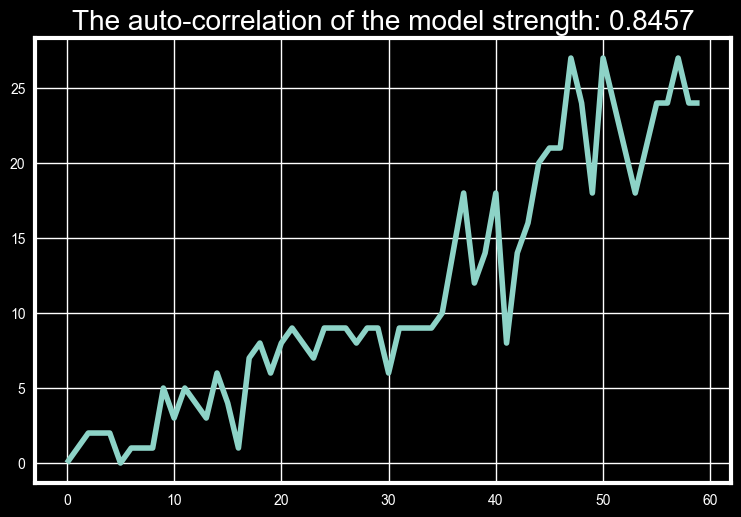

In [125]:
# Difficulty estimation

strength_significance = .7

strength_corr = autocorr("strength")
if strength_corr < .7:
    print(f"[Warn] The current model tends not to improve over time, as indicated by the auto-correlation value: {strength_corr:.4f} < {strength_significance}")
    print(f"[Warn] Either the evaluation step is too harsh for the current model, or the model does not learn")

axes = df["strength"].plot()
axes.set_title(f"The auto-correlation of the model strength: {strength_corr:.4f}")